In [1]:
print("all ok")

all ok


In [1]:
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI

In [5]:
# llm=ChatGroq(model="meta-llama/llama-4-maverick-17b-128e-instruct")
llm = ChatOpenAI(model_name="gpt-4o", temperature=0)

In [6]:
print(llm.invoke("What is the capital of France?").content)

The capital of France is Paris.


In [7]:
print(llm.invoke("What is the capital of india tell me in detail?").content)

The capital of India is New Delhi. It serves as the seat of all three branches of the government of India, hosting the Rashtrapati Bhavan (Presidential Residence), the Parliament of India, and the Supreme Court of India.

### Historical Background:
- **Foundation**: New Delhi was officially inaugurated as the capital of India on February 13, 1931. The city was designed by British architects Sir Edwin Lutyens and Sir Herbert Baker.
- **Reason for Capital Shift**: The capital was moved from Calcutta (now Kolkata) to Delhi in 1911 during the British colonial period. The decision was partly due to Delhi's historical significance and its strategic location in the northern part of India.

### Geographical and Administrative Details:
- **Location**: New Delhi is situated within the larger National Capital Territory (NCT) of Delhi, which is bordered by the states of Haryana and Uttar Pradesh.
- **Area**: New Delhi itself is a small part of the NCT, covering an area of approximately 42.7 square

In [8]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
search_tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

C:\Users\DELL\AppData\Local\Temp\ipykernel_3472\156554669.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  search_tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)


In [9]:
search_tool.invoke("What is the capital of France?")

[{'title': 'List of capitals of France - Wikipedia',
  'url': 'https://en.wikipedia.org/wiki/List_of_capitals_of_France',
  'content': 'This is a chronological list of capitals of France. The capital of France has been Paris since its liberation in 1944.\n\n## Chronology\n\n[edit] [...] Tours (10–13 June 1940), the city served as the temporary capital of France during World War II after the government fled Paris due to the German advance.\n Bordeaux (June 1940), the government was relocated from Paris to Tours then Bordeaux very briefly during World War II, when it became apparent that Paris would soon fall into German hands. [...] Paris (1789–1871), on 5 and 6 October 1789, a throng from Paris invaded the castle and forced the royal family to move back to Paris. The National Constituent Assembly "National Constituent Assembly (France)") followed the King to Paris soon afterward; Versailles lost its role of capital city.',
  'score': 0.8993429},
 {'title': 'Paris facts: the capital of 

In [10]:
my_code = """
x=10
y=x+10
print(y)
"""

In [11]:
from langchain_experimental.utilities import PythonREPL

In [12]:
repl=PythonREPL()

In [13]:
repl.run(my_code)

Python REPL can execute arbitrary code. Use with caution.


'20\n'

In [14]:
repl.invoke(my_code)

AttributeError: 'PythonREPL' object has no attribute 'invoke'

In [17]:
from typing import Annotated

In [18]:
from langchain_core.tools import tool

In [19]:
@tool
def python_repl_tool(code: Annotated[str, "The python code to execute to generate your chart."]):
    """Use this to execute python code and do math. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return result_str

<>:11: SyntaxWarning: invalid escape sequence '\`'
<>:11: SyntaxWarning: invalid escape sequence '\`'
<>:11: SyntaxWarning: invalid escape sequence '\`'
<>:11: SyntaxWarning: invalid escape sequence '\`'
C:\Users\DELL\AppData\Local\Temp\ipykernel_3472\2860116823.py:11: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
C:\Users\DELL\AppData\Local\Temp\ipykernel_3472\2860116823.py:11: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"


In [20]:
python_repl_tool.invoke("x=10\ny=x+10\nprint(y)")

'Successfully executed:\n\\`\\`\\`python\nx=10\ny=x+10\nprint(y)\n\\`\\`\\`\nStdout: 20\n'

In [21]:
python_repl_tool.invoke(my_code)

'Successfully executed:\n\\`\\`\\`python\n\nx=10\ny=x+10\nprint(y)\n\n\\`\\`\\`\nStdout: 20\n'

### WE HAVE TWO SUB AGENT 
1. RESEARCHER- internet
2. CODER- executing the code

In [22]:
members=["researcher","coder"]

In [23]:
members

['researcher', 'coder']

In [24]:
options = members+["FINISH"]

In [25]:
options

['researcher', 'coder', 'FINISH']

In [26]:
from typing import Literal

In [27]:
from typing_extensions import TypedDict

## There is no routing logic
### it is simply going to return the next candidate(next_agent)
### this next is containig the next candidate name

In [28]:
class Router(TypedDict):
    next: Literal['researcher', 'coder', 'FINISH']

In [29]:
from langgraph.graph import MessagesState,StateGraph,START, END
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

#### this is a messagesstate which we are loading from the langgraph(inbuilt message state)

In [30]:
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [31]:
class State(MessagesState):
    next:str

##### this is how my state will be looking like

In [32]:
class State(MessagesState):
    next:str
state={"messages": ["hi"], "next": "research_agent"}

In [33]:
system_prompt = f""""
You are a supervisor, tasked with managing a conversation between the following workers: {members}. 
Given the following user request, respond with the worker to act next. 
Each worker will perform a task and respond with their results and status. 
When finished, respond with FINISH.
"""

In [30]:
# system_prompt = f""""
# You are a supervisor, tasked with managing a conversation between the following workers: {members}. 
# Given the following user request, respond with the worker to act next. 
# Each worker will perform a task and respond with their results and status. 
# When finished, respond with FINISH.
# **Strict Guidelines:**
# if there is any common messages like hi, hello, how are you, greetings etc then,respond with FINISH.
# """

In [34]:
# system_prompt = f"""
# You are a supervisor managing a task delegation system with the following workers: {members}.

# Your job is to decide which worker should act next based on the user’s input.

# Guidelines:
# - Carefully read the user’s message.
# - If the message clearly requires a specific action (e.g., search, compute, rewrite), assign it to the appropriate worker.
# - If the message is general, conversational, or does **not** require any specific action, immediately respond with `FINISH`.
# - Do **not** invent tasks or assign actions unless the message clearly demands it.

# Each worker will return results after completing their task.
# Once all necessary tasks are completed, end the flow by responding with `FINISH`.

# Be strict — if the message is casual, rhetorical, or lacks a clear task, reply with `FINISH`.
# """


In [35]:
print(system_prompt)

"
You are a supervisor, tasked with managing a conversation between the following workers: ['researcher', 'coder']. 
Given the following user request, respond with the worker to act next. 
Each worker will perform a task and respond with their results and status. 
When finished, respond with FINISH.



In [37]:
state

{'messages': ['hi'], 'next': 'research_agent'}

In [38]:
messages = [{"role": "system", "content": system_prompt},] + state["messages"]

In [39]:
messages

[{'role': 'system',
  'content': '"\nYou are a supervisor, tasked with managing a conversation between the following workers: [\'researcher\', \'coder\']. \nGiven the following user request, respond with the worker to act next. \nEach worker will perform a task and respond with their results and status. \nWhen finished, respond with FINISH.\n'},
 'hi']

[{'role': 'system',
  'content': '"\nYou are a supervisor, tasked with managing a conversation between the following workers: [\'researcher\', \'coder\']. \nGiven the following user request, respond with the worker to act next. \nEach worker will perform a task and respond with their results and status. \nWhen finished, respond with FINISH.\n**Strict Guidelines:**\nif there is any common messages like hi, hello, how are you, greetings etc then,respond with FINISH.\n'},
 'hi']

In [40]:
llm_with_structure_output=llm.with_structured_output(Router)

In [41]:
llm_with_structure_output.invoke(messages)

{'next': 'researcher'}

#### you can try out with this prompt also

#### This is my all three agents

In [42]:
from langgraph.types import Command

In [43]:
def supervisor_agent(state:State)->Command[Literal['researcher', 'coder', '__end__']]:
    
    messages = [{"role": "system", "content": system_prompt},] + state["messages"]
    
    llm_with_structure_output=llm.with_structured_output(Router)
    
    response=llm_with_structure_output.invoke(messages)
    
    #this is my response {'next': 'researcher'}
    
    #this is my next worker agent
    goto=response["next"]
    
    print("**********BELOW IS MY GOTO***************")
    
    print(goto)
    
    if goto == "FINISH":
        goto=END
    
    # class State(MessagesState):
    #   next:str
    # output of the state: state={"messages": ["hi"], "next": "researcher"}
    
    return Command(goto=goto, update={"next":goto})

In [44]:
from langgraph.prebuilt import create_react_agent

In [45]:
from langchain_core.messages import AIMessage, HumanMessage

In [46]:
def research_agent(state: State) -> Command[Literal["supervisor"]]:
    
    research_agent = create_react_agent(llm, tools=[search_tool], prompt="You are a researcher. DO NOT do any math.")
    
    result=research_agent.invoke(state)
    
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="researcher")
            ]
        },
        goto="supervisor",
    )
    

In [47]:
def coder_agent(state:State)->Command[Literal['supervisor']]:
    code_agent=create_react_agent(llm,tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")
    result=code_agent.invoke(state)
    
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="coder")
            ]
        },
        goto="supervisor",
    )
    

#### this is my orchestration flow with langgraph

In [48]:
graph=StateGraph(State)

In [49]:
graph.add_node("supervisor", supervisor_agent)

In [50]:
graph.add_node("researcher", research_agent)

In [51]:
graph.add_node("coder", coder_agent)

In [52]:
graph.add_edge(START, "supervisor")

In [53]:
app=graph.compile()

In [54]:
from IPython.display import display,Image

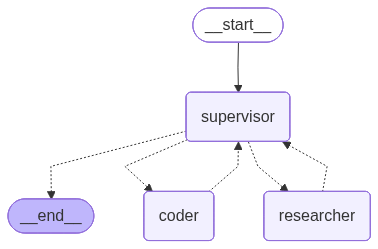

In [55]:
display(Image(app.get_graph().draw_mermaid_png()))

In [56]:
for s in app.stream({"messages": [("user", "What's the square root of 42?")]}, subgraphs=True):
    print(s)
    print("**********BELOW IS MY STATE***************")

**********BELOW IS MY GOTO***************
coder
((), {'supervisor': {'next': 'coder'}})
**********BELOW IS MY STATE***************


C:\Users\DELL\AppData\Local\Temp\ipykernel_3472\2396260197.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent=create_react_agent(llm,tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")


(('coder:6ef56dc0-2c91-b42e-e4df-09569a8bcf59',), {'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_BlKFVBHIsT13W3Z4LofERXkI', 'function': {'arguments': '{"code":"import math\\nmath.sqrt(42)"}', 'name': 'python_repl_tool'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 107, 'total_tokens': 130, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a788c5aef0', 'id': 'chatcmpl-CUd9Iteg9air3nHOxVwrJVf67qLX5', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--d6c0037d-7786-469a-9930-4be473e39a9c-0', tool_calls=[{'name': 'python_repl_tool', 'args': {'code': 'import math\nmath.sqrt(42)'}, 'id': 'call_BlKFVBHIsT13W3Z4LofERXkI', 'type':

In [57]:
s

((), {'supervisor': {'next': '__end__'}})

In [58]:
result=app.invoke({"messages": [("user", "what is an efficent python code to get prime number?")]}, subgraphs=True)

**********BELOW IS MY GOTO***************
coder


C:\Users\DELL\AppData\Local\Temp\ipykernel_3472\2396260197.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent=create_react_agent(llm,tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")


**********BELOW IS MY GOTO***************
FINISH


In [59]:
result

{'messages': [HumanMessage(content='what is an efficent python code to get prime number?', additional_kwargs={}, response_metadata={}, id='08d7aba3-131a-4eac-83f5-9eb690da46d9'),
  HumanMessage(content="An efficient way to find prime numbers in Python is by using the Sieve of Eratosthenes algorithm. This algorithm efficiently finds all prime numbers up to a given limit. Here's a Python implementation:\n\n```python\ndef sieve_of_eratosthenes(limit):\n    primes = []\n    is_prime = [True] * (limit + 1)\n    p = 2\n    while p * p <= limit:\n        if is_prime[p]:\n            for i in range(p * p, limit + 1, p):\n                is_prime[i] = False\n        p += 1\n    for p in range(2, limit + 1):\n        if is_prime[p]:\n            primes.append(p)\n    return primes\n\n# Example usage:\nlimit = 100\nprime_numbers = sieve_of_eratosthenes(limit)\nprint(prime_numbers)\n```\n\nThis code will output all prime numbers up to the specified limit. The Sieve of Eratosthenes is efficient for

In [60]:
result=app.invoke({"messages": [("user", "what is an efficent python code to get prime number?")]}, subgraphs=True)

**********BELOW IS MY GOTO***************
researcher


C:\Users\DELL\AppData\Local\Temp\ipykernel_3472\2060188370.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(llm, tools=[search_tool], prompt="You are a researcher. DO NOT do any math.")


**********BELOW IS MY GOTO***************
coder


C:\Users\DELL\AppData\Local\Temp\ipykernel_3472\2396260197.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent=create_react_agent(llm,tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")


**********BELOW IS MY GOTO***************
FINISH


In [61]:
result

{'messages': [HumanMessage(content='what is an efficent python code to get prime number?', additional_kwargs={}, response_metadata={}, id='b75392f5-b468-412b-bdd5-d4d541fb6f1f'),
  HumanMessage(content="To find prime numbers efficiently in Python, you can use the Sieve of Eratosthenes algorithm. This algorithm is efficient for finding all prime numbers up to a specified integer. Here's a simple implementation:\n\n```python\ndef sieve_of_eratosthenes(n):\n    primes = []\n    is_prime = [True] * (n + 1)\n    p = 2\n    while p * p <= n:\n        if is_prime[p]:\n            for i in range(p * p, n + 1, p):\n                is_prime[i] = False\n        p += 1\n    for p in range(2, n + 1):\n        if is_prime[p]:\n            primes.append(p)\n    return primes\n\n# Example usage:\nn = 100\nprime_numbers = sieve_of_eratosthenes(n)\nprint(prime_numbers)\n```\n\nThis code defines a function `sieve_of_eratosthenes` that takes an integer `n` and returns a list of all prime numbers up to `n`